<a href="https://colab.research.google.com/github/nyp-sit/iti121-2025s2/blob/main/L9/timeseries_classification_rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Timeseries classification using PyTorch RNN

## Introduction

In this lab exercise, we will apply a simple RNN using PyTorch to do timeseries classification.

*The lab is adapted from the example codes on keras.io and converted to use PyTorch*

## Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.model_selection import train_test_split

## Load the data: the FordA dataset

### Dataset description

The dataset we are using here is called FordA.
The data comes from the UCR archive.
The dataset contains 3601 training instances and another 1320 testing instances.
Each timeseries corresponds to a measurement of engine noise captured by a motor sensor.
For this task, the goal is to automatically detect the presence of a specific issue with
the engine. The problem is a balanced binary classification task. The full description of
this dataset can be found [here](http://www.j-wichard.de/publications/FordPaper.pdf).

### Read the data

We will use the `FordA_TRAIN` file for training and the
`FordA_TEST` file for testing. The simplicity of this dataset
allows us to demonstrate effectively how to use PyTorch RNN for timeseries classification.
In this file, the first column corresponds to the label.

In [2]:
train_df = pd.read_csv('FordA_TRAIN.txt', sep="\s+", header=None)
train_df

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1437233877.py:1: SyntaxWarning: invalid escape sequence '\s'
  train_df = pd.read_csv('FordA_TRAIN.txt', sep="\s+", header=None)


,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,-1.0,-0.797172,-0.664392,-0.373015,0.040815,0.526936,0.984288,1.353120,1.578108,1.659251,...,1.120756,0.722417,0.362068,0.092083,-0.081268,-0.212573,-0.391456,-0.664392,-1.073796,-1.564343
1,1.0,0.804855,0.634629,0.373474,0.038343,-0.340988,-0.740860,-1.109667,-1.395357,-1.570192,...,0.386403,0.049213,-0.258138,-0.510583,-0.683647,-0.773817,-0.785255,-0.714885,-0.560443,-0.319086
2,-1.0,0.727985,0.111284,-0.499124,-1.068629,-1.578351,-1.990534,-2.302031,-2.503403,-2.585211,...,0.394463,0.463685,0.507735,0.517174,0.504588,0.476270,0.438513,0.394463,0.339400,0.255391
3,-1.0,-0.234439,-0.502157,-0.732488,-0.946128,-1.139739,-1.323336,-1.490243,-1.607077,-1.620430,...,-0.952804,-0.929437,-0.922761,-0.929437,-0.909409,-0.835970,-0.695768,-0.478790,-0.188707,0.119736
4,-1.0,-0.171328,-0.062285,0.235829,0.710396,1.239969,1.649823,1.876321,1.865535,1.703751,...,0.776188,0.725496,0.697453,0.731967,0.808545,0.839823,0.733046,0.437520,-0.026585,-0.602213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3596,-1.0,0.196022,-0.070102,-0.336226,-0.516799,-0.555282,-0.442793,-0.221369,0.025217,0.233320,...,1.715205,1.129082,0.528158,-0.039020,-0.573043,-1.061479,-1.514392,-1.934743,-2.316612,-2.603753
3597,1.0,0.041994,0.422255,0.740529,0.975426,1.109891,1.137270,1.058349,0.894955,0.671224,...,-0.463329,-0.392667,-0.333749,-0.316543,-0.340299,-0.392876,-0.450805,-0.482609,-0.467769,-0.393755
3598,-1.0,-0.570054,-0.333165,-0.293519,-0.425344,-0.590869,-0.615648,-0.348033,0.275412,1.153586,...,0.902821,0.579700,0.157463,-0.353980,-0.885246,-1.314421,-1.512655,-1.393714,-0.942733,-0.270722
3599,1.0,2.006732,2.079150,2.022036,1.867560,1.648112,1.379446,1.093717,0.784057,0.434150,...,1.268671,1.148971,0.928088,0.634953,0.311682,-0.007376,-0.270543,-0.432145,-0.441231,-0.280709


In [3]:
test_df = pd.read_csv('FordA_TEST.txt', sep="\s+", header=None)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1883031804.py:1: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv('FordA_TEST.txt', sep="\s+", header=None)


In [4]:
x_train, y_train = train_df.loc[:,1:].values, train_df.loc[:,0].values
x_test, y_test = test_df.loc[:,1:].values, test_df.loc[:,0].values

# Convert to PyTorch tensors
x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)
x_test = torch.FloatTensor(x_test)
y_test = torch.LongTensor(y_test)

In [5]:
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training data shape: torch.Size([3601, 500])
Training labels shape: torch.Size([3601])
Test data shape: torch.Size([1320, 500])
Test labels shape: torch.Size([1320])


## Visualize the data

Here we visualize one timeseries example for each class in the dataset.

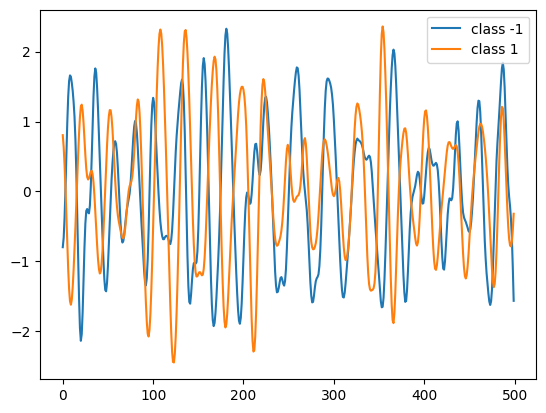

In [6]:
classes = torch.unique(torch.cat((y_train, y_test), dim=0))

plt.figure()
for c in classes:
    c_x_train = x_train[y_train == c]
    plt.plot(c_x_train[0].numpy(), label="class " + str(c.item()))
plt.legend()
plt.show()
plt.close()

## Standardize the data

Our timeseries are already in a single length (500). However, their values are
usually in various ranges. This is not ideal for a neural network;
in general we should seek to make the input values normalized.
For this specific dataset, the data is already z-normalized: each timeseries sample
has a mean equal to zero and a standard deviation equal to one.

Note that the timeseries data used here are univariate, meaning we only have one channel
per timeseries example.
We will therefore transform the timeseries into a multivariate one with one channel
using a simple reshaping via PyTorch.
This will allow us to construct a model that is easily applicable to multivariate time
series.

In [7]:
# Add channel dimension for PyTorch (batch_size, sequence_length, input_size)
x_train = x_train.unsqueeze(2)  # Add channel dimension
x_test = x_test.unsqueeze(2)    # Add channel dimension

In [8]:
x_train.shape

torch.Size([3601, 500, 1])

Finally, in order to use `CrossEntropyLoss`, we will have to count
the number of classes beforehand.

In [9]:
num_classes = len(torch.unique(y_train))

Now we shuffle the training set because we will be using a validation split
later when training.

In [10]:
# Shuffle the training data
perm = torch.randperm(len(x_train))
x_train = x_train[perm]
y_train = y_train[perm]

Standardize the labels to positive integers.
The expected labels will then be 0 and 1.

In [11]:
# Standardize the labels to positive integers.
# The expected labels will then be 0 and 1.
y_train[y_train == -1] = 0
y_test[y_test == -1] = 0

## Build a PyTorch RNN model

We use a single RNN layer to capture the temporal information and return the hidden states at each timestep. We then feed these timesteps into the dense layers for classification.

Note that we set the `batch_first=True` to have the batch dimension first. The output shape is thus of 3D shape (batch, time-steps, hidden_size). We then apply a linear layer to every time step and finally use a final linear layer for classification.

In [12]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, num_layers=2):
        super(RNNClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # RNN layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)

        # Use attention or global pooling to aggregate all timesteps
        self.attention = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Initialize hidden state on the same device as input
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)

        # RNN forward pass
        out, _ = self.rnn(x, h0)  # (batch_size, seq_len, hidden_size)

        # Apply attention mechanism to weight all timesteps
        attention_weights = self.attention(out)  # (batch_size, seq_len, 1)
        attention_weights = torch.softmax(attention_weights, dim=1)  # Normalize weights

        # Weighted sum of all timesteps
        weighted_output = torch.sum(out * attention_weights, dim=1)  # (batch_size, hidden_size)

        # Apply dropout and final classification
        weighted_output = self.dropout(weighted_output)
        output = self.fc(weighted_output)  # (batch_size, num_classes)

        return output

# Create model
input_size = x_train.shape[2]  # Number of features per timestep
hidden_size = 32
model = RNNClassifier(input_size, hidden_size, num_classes)

print(f"Model created with input_size={input_size}, hidden_size={hidden_size}, num_classes={num_classes}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

Model created with input_size=1, hidden_size=32, num_classes=2
Total parameters: 3331


## Train the PyTorch model

In [13]:
# Training parameters
epochs = 250
batch_size = 256
learning_rate = 0.001

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move model to device
model = model.to(device)

# Create data loaders
def create_data_loaders(x_train, y_train, x_test, y_test, batch_size, validation_split=0.2):
    # Split training data for validation
    train_size = int((1 - validation_split) * len(x_train))
    x_train_split = x_train[:train_size]
    y_train_split = y_train[:train_size]
    x_val_split = x_train[train_size:]
    y_val_split = y_train[train_size:]

    # Create datasets
    train_dataset = TensorDataset(x_train_split, y_train_split)
    val_dataset = TensorDataset(x_val_split, y_val_split)
    test_dataset = TensorDataset(x_test, y_test)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = create_data_loaders(x_train, y_train, x_test, y_test, batch_size)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("Starting training...")

Using device: cuda
Starting training...


In [14]:
# Training loop with early stopping
best_val_acc = 0
patience = 50
patience_counter = 0

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()

    # Validation phase
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()

    # Calculate average losses and accuracies
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    # Store metrics
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}')

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

print('Training completed!')


Epoch [10/250], Train Loss: 0.6936, Train Acc: 0.4924, Val Loss: 0.6928, Val Acc: 0.5118
Epoch [20/250], Train Loss: 0.6927, Train Acc: 0.5146, Val Loss: 0.6890, Val Acc: 0.4508
Epoch [30/250], Train Loss: 0.4181, Train Acc: 0.8017, Val Loss: 0.4007, Val Acc: 0.8294
Epoch [40/250], Train Loss: 0.3567, Train Acc: 0.8399, Val Loss: 0.3550, Val Acc: 0.8558
Epoch [50/250], Train Loss: 0.3500, Train Acc: 0.8396, Val Loss: 0.3952, Val Acc: 0.7933
Epoch [60/250], Train Loss: 0.3254, Train Acc: 0.8458, Val Loss: 0.3313, Val Acc: 0.8544
Epoch [70/250], Train Loss: 0.3129, Train Acc: 0.8583, Val Loss: 0.3244, Val Acc: 0.8571
Epoch [80/250], Train Loss: 0.2975, Train Acc: 0.8590, Val Loss: 0.3520, Val Acc: 0.8350
Epoch [90/250], Train Loss: 0.2879, Train Acc: 0.8642, Val Loss: 0.3088, Val Acc: 0.8627
Epoch [100/250], Train Loss: 0.2808, Train Acc: 0.8826, Val Loss: 0.2999, Val Acc: 0.8669
Epoch [110/250], Train Loss: 0.2607, Train Acc: 0.8892, Val Loss: 0.2824, Val Acc: 0.8696
Epoch [120/250], Tr

## Evaluate PyTorch model on test data

In [17]:
# Load the best model
model.load_state_dict(torch.load('best_model.pth'))

# Evaluate on test data
model.eval()
test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        test_total += batch_y.size(0)
        test_correct += (predicted == batch_y).sum().item()

test_accuracy = test_correct / test_total
avg_test_loss = test_loss / len(test_loader)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {avg_test_loss:.4f}")

Test accuracy: 0.9015
Test loss: 0.2240


## Visualize training using matplotlib

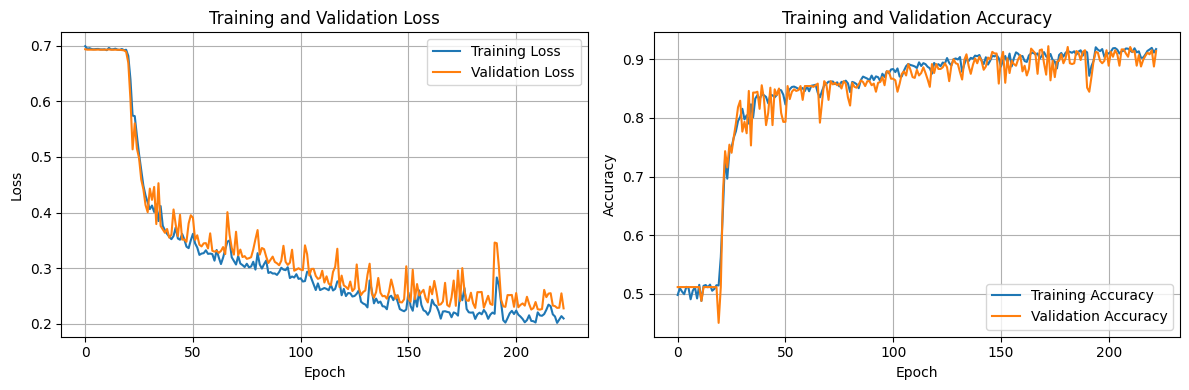

In [18]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot losses
ax1.plot(train_losses, label='Training Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot accuracies
ax2.plot(train_accuracies, label='Training Accuracy')
ax2.plot(val_accuracies, label='Validation Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

We can see how that the validation accuracy is quite close to the training accuracy.